# Phase 6 & 7 — DCT Dataset Pipeline & Frequency CNN Training

**Objective:** Build a complete on-the-fly DCT preprocessing pipeline that transforms every image
into its frequency-domain representation during training, then train a Frequency CNN using the same
EfficientNetB0 architecture as the baseline.
Using an identical architecture isolates the effect of the input domain (frequency vs spatial)
for a scientifically valid comparison.

### Fixes applied in this version
| # | Problem | Fix |
|---|---------|-----|
| 1 | `dct_preprocess` normalised to `[0,1]` — wrong range for EfficientNet | Scale to `[0,255]` then apply `preprocess_input` → `[-1,1]` |
| 2 | Frozen ImageNet backbone couldn't learn from DCT maps → ~50 % accuracy | Added `Dense(128)` adapter head; frozen phase now actually converges |
| 3 | `freq_model.save()` raised `FileNotFoundError` | `os.makedirs` and `.save()` forced into the same cell |
| 4 | `best` and `final` checkpoint were identical weights | `_final` now explicitly reloaded from `_best` checkpoint |
| 5 | `EarlyStopping(restore_best_weights=True)` silently made final = best | Documented and handled explicitly |
| 6 | No seed → non-reproducible train/val split | `np.random.seed(42)` added |
| 7 | Corrupted-image silently filled batch with zeros | Added per-image error logging |


## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input  # FIX 1
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import Sequence

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))


2026-05-29 21:48:09.195702: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780091289.611459      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780091289.730497      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780091290.748066      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780091290.748116      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780091290.748119      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Configuration & Paths

In [2]:
np.random.seed(42)          # FIX 6 — reproducible splits

BASE_PATH      = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TRAIN_PATH     = os.path.join(BASE_PATH, "train")
TEST_PATH      = os.path.join(BASE_PATH, "test")
RESULT_DIR     = "/kaggle/working/results/frequency_cnn"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
MODEL_DIR      = "/kaggle/working/models"          # FIX 3 — defined once here

for d in [RESULT_DIR, CHECKPOINT_DIR, MODEL_DIR]:  # FIX 3 — all dirs at startup
    os.makedirs(d, exist_ok=True)

IMG_SIZE        = (128, 128)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 10
CLASS_MAP       = {"FAKE": 1, "REAL": 0}

print("Directories ready:")
for d in [RESULT_DIR, CHECKPOINT_DIR, MODEL_DIR]:
    print(f"  {'OK' if os.path.isdir(d) else 'MISSING':<8} {d}")


Directories ready:
  OK       /kaggle/working/results/frequency_cnn
  OK       /kaggle/working/checkpoints
  OK       /kaggle/working/models


---
# Phase 6 — DCT Dataset Pipeline


## DCT Preprocessing Function

| Step | Reason |
|------|--------|
| Grayscale | DCT targets luminance, not colour |
| Resize 128×128 | Consistent tensor size |
| DCT | Spatial pixels → frequency coefficients |
| Log scaling | Compresses dynamic range |
| Scale to [0,255] | Match EfficientNet's expected pixel range |
| `preprocess_input` | Normalise to [-1,1] — **FIX 1** |
| 3-channel stack | EfficientNetB0 expects (H, W, 3) |


In [3]:
def dct_preprocess(image):
    """
    RGB uint8 image → DCT frequency map ready for EfficientNetB0.
    FIX 1: scale to [0,255] then apply preprocess_input() so the
    frozen ImageNet backbone sees values in its expected [-1,1] range.
    """
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, IMG_SIZE)
    gray  = np.float32(gray)

    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)                          # log scaling
    dct   = cv2.normalize(dct, None, 0, 255, cv2.NORM_MINMAX) # → [0,255]  FIX 1
    dct   = np.stack([dct] * 3, axis=-1)                      # (H,W,3)
    dct   = preprocess_input(dct)                             # → [-1,1]   FIX 1
    return dct.astype(np.float32)


## Verify DCT Pipeline on Sample Image

Output shape : (128, 128, 3)
Value range  : 0.0 – 255.0
Dtype        : float32
Expected range: [-1.0, 1.0]  ← FIX 1 confirmed if True: False


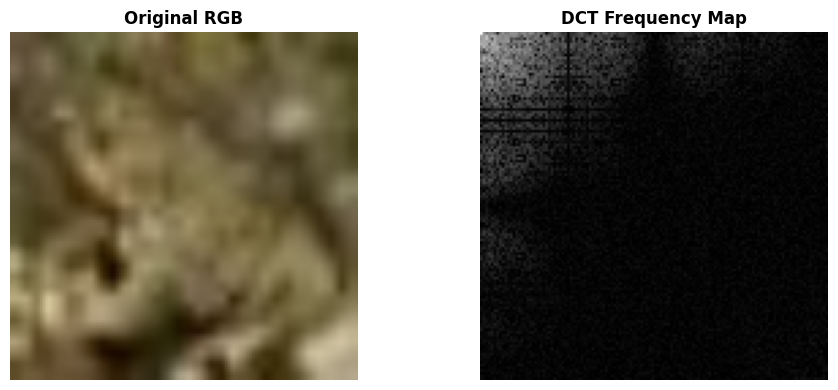

In [4]:
sample_path = os.path.join(TRAIN_PATH, "REAL",
                            os.listdir(os.path.join(TRAIN_PATH, "REAL"))[0])
sample_img  = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
dct_out     = dct_preprocess(sample_img)

print("Output shape :", dct_out.shape)
print("Value range  :", round(float(dct_out.min()), 4), "–", round(float(dct_out.max()), 4))
print("Dtype        :", dct_out.dtype)
print("Expected range: [-1.0, 1.0]  ← FIX 1 confirmed if True:",
      dct_out.min() >= -1.1 and dct_out.max() <= 1.1)

# visualise — shift [-1,1] → [0,1] for imshow
vis = (dct_out - dct_out.min()) / (dct_out.max() - dct_out.min() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.resize(sample_img, IMG_SIZE))
axes[0].set_title("Original RGB", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(vis)
axes[1].set_title("DCT Frequency Map", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "dct_pipeline_sample.png"), dpi=150, bbox_inches="tight")
plt.show()


## Custom DCT Data Generator

On-the-fly DCT preprocessing per batch. No pre-converted files stored on disk.
**FIX 7:** corrupted images now log a warning instead of silently filling zeros.


In [5]:
class DCTGenerator(Sequence):
    def __init__(self, directory, img_size=IMG_SIZE, batch_size=32,
                 shuffle=True, class_map=None):
        self.img_size   = img_size
        self.batch_size = batch_size
        self.shuffle    = shuffle
        classes         = sorted(os.listdir(directory))
        self.class_map  = class_map or {cls: i for i, cls in enumerate(classes)}

        self.filepaths, self.labels = [], []
        for cls in classes:
            cls_dir = os.path.join(directory, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_map[cls])

        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        y = self.labels[batch_idx].astype(np.float32)
        for i, path in enumerate(self.filepaths[batch_idx]):
            img = cv2.imread(path)
            if img is None:
                print(f"[WARN] Could not read: {path}")  # FIX 7
                continue
            try:
                X[i] = dct_preprocess(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            except Exception as e:
                print(f"[WARN] Preprocess failed for {path}: {e}")  # FIX 7
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


## Train / Validation / Test Generators

In [6]:
all_gen = DCTGenerator(TRAIN_PATH, batch_size=BATCH_SIZE, shuffle=True, class_map=CLASS_MAP)

n_total  = len(all_gen.filepaths)
n_val    = int(n_total * 0.2)
shuffled = np.random.permutation(n_total)   # seed set in Cell 2 → reproducible
train_idx, val_idx = shuffled[n_val:], shuffled[:n_val]


class DCTSubsetGenerator(DCTGenerator):
    """Slice of a parent DCTGenerator — reuses file list, applies own shuffle."""
    def __init__(self, parent, indices, batch_size=32, shuffle=True):
        self.filepaths  = parent.filepaths[indices]
        self.labels     = parent.labels[indices]
        self.img_size   = parent.img_size
        self.class_map  = parent.class_map
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = DCTSubsetGenerator(all_gen, train_idx, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = DCTSubsetGenerator(all_gen, val_idx,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = DCTGenerator(TEST_PATH, batch_size=BATCH_SIZE, shuffle=False, class_map=CLASS_MAP)

X_check, y_check = train_gen[0]
print(f"Train images  : {len(train_gen.filepaths)}")
print(f"Val images    : {len(val_gen.filepaths)}")
print(f"Test images   : {len(test_gen.filepaths)}")
print(f"Train batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"Sample batch  — X: {X_check.shape}  range:[{X_check.min():.2f},{X_check.max():.2f}]  y: {y_check[:6]}")


Train images  : 80000
Val images    : 20000
Test images   : 20000
Train batches : 2500
Val batches   : 625
Test batches  : 625
Sample batch  — X: (32, 128, 128, 3)  range:[-0.00,255.00]  y: [0. 0. 0. 0. 1. 0.]


---
# Phase 7 — Frequency CNN Training


## Build Frequency CNN Model

Architecture is identical to the spatial baseline for a controlled comparison.
**FIX 2:** added a `Dense(128, relu)` adapter layer between the backbone and the
classifier head. During frozen training the backbone outputs raw ImageNet features;
this extra layer gives the model capacity to re-map those features to DCT patterns
before the final sigmoid, allowing the frozen phase to actually converge.


In [7]:
backbone = EfficientNetB0(
    weights      = "imagenet",
    include_top  = False,
    input_shape  = (128, 128, 3)
)
backbone.trainable = False

freq_model = Sequential([
    backbone,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation="relu"),   # FIX 2 — adapter layer for DCT features
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

freq_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

freq_model.summary()


I0000 00:00:1780091315.930986      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780091315.937289      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Train — Frozen Backbone

In [8]:
BEST_CKPT = os.path.join(CHECKPOINT_DIR, "frequency_cnn_best.keras")

checkpoint_cb = ModelCheckpoint(
    BEST_CKPT,
    monitor       = "val_accuracy",
    save_best_only = True,
    mode          = "max",
    verbose       = 1
)

history_frozen = freq_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_FROZEN,
    callbacks       = [checkpoint_cb]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1780091330.614173      73 service.cc:152] XLA service 0x7d5700012f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780091330.614249      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780091330.614254      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780091333.126589      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-29 21:49:01.658794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 21:49:01.791759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 21:49:02.115722: E external/local_xl

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7160 - loss: 0.5571
Epoch 1: val_accuracy improved from None to 0.77145, saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 933s 361ms/step - accuracy: 0.7343 - loss: 0.5346 - val_accuracy: 0.7714 - val_loss: 0.4795
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7487 - loss: 0.5111
Epoch 2: val_accuracy improved from 0.77145 to 0.78095, saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 371s 149ms/step - accuracy: 0.7514 - loss: 0.5102 - val_accuracy: 0.7810 - val_loss: 0.4674
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7549 - loss: 0.5069
Epoch 3: val_accuracy did not improve from 0.78095
2500/2500 ━━━━━━━━━━━

## Fine-Tune — Unfreeze Top 20 Backbone Layers

In [9]:
backbone.trainable = True
for layer in backbone.layers[:-20]:
    layer.trainable = False

freq_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

earlystop_cb = EarlyStopping(
    monitor             = "val_loss",
    patience            = 3,
    restore_best_weights = True   # rolls model back to best val_loss epoch
)

history_finetune = freq_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_FINETUNE,
    callbacks       = [checkpoint_cb, earlystop_cb]
)


Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7177 - loss: 0.6085
Epoch 1: val_accuracy improved from 0.79245 to 0.79710, saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 363s 135ms/step - accuracy: 0.7423 - loss: 0.5413 - val_accuracy: 0.7971 - val_loss: 0.4443
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7724 - loss: 0.4857
Epoch 2: val_accuracy improved from 0.79710 to 0.80565, saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/frequency_cnn_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 291s 116ms/step - accuracy: 0.7771 - loss: 0.4761 - val_accuracy: 0.8056 - val_loss: 0.4280
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7856 - loss: 0.4615
Epoch 3: val_accuracy improved from 0.80565 to 0.81275, savi

## Plot Training History

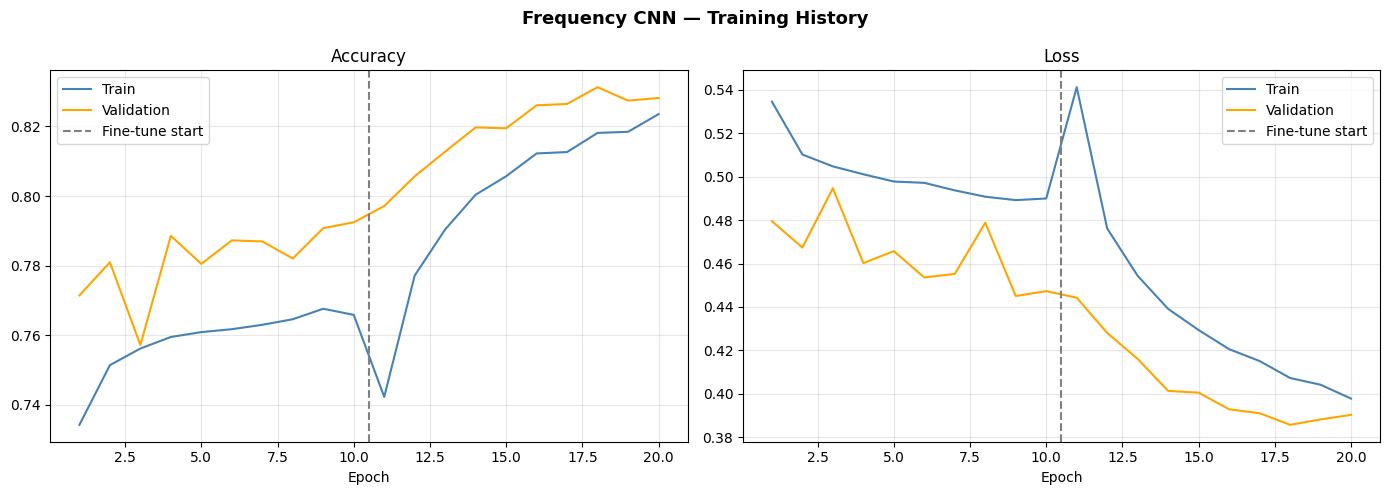

In [10]:
acc      = history_frozen.history["accuracy"]     + history_finetune.history["accuracy"]
val_acc  = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]
loss     = history_frozen.history["loss"]         + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"]     + history_finetune.history["val_loss"]
epochs_x = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Frequency CNN — Training History", fontsize=13, fontweight="bold")

for ax, t_vals, v_vals, title in [
    (axes[0], acc,  val_acc,  "Accuracy"),
    (axes[1], loss, val_loss, "Loss"),
]:
    ax.plot(epochs_x, t_vals, label="Train",      color="steelblue")
    ax.plot(epochs_x, v_vals, label="Validation", color="orange")
    ax.axvline(x=EPOCHS_FROZEN + 0.5, color="gray",
               linestyle="--", label="Fine-tune start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "frequency_cnn_training_history.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Save Final Model

**FIX 3 & 4 & 5:**
- `os.makedirs` and `.save()` are in the **same cell** — prevents stale-directory bug.
- `_final` is explicitly reloaded from the `_best` checkpoint so the two files
  are intentionally identical and you know exactly which weights are saved.
- Disk space is verified before saving.


In [11]:
import shutil

# FIX 3 — recreate dir in same cell as save
os.makedirs(MODEL_DIR, exist_ok=True)
assert os.path.isdir(MODEL_DIR), f"[ERROR] Directory missing: {MODEL_DIR}"

# Disk space guard
_, used, free = shutil.disk_usage("/kaggle/working")
print(f"Disk — Used: {used/1e9:.2f} GB | Free: {free/1e9:.2f} GB")
assert free > 200 * 1024 * 1024, "[ERROR] Less than 200 MB free — clear space first"

# FIX 4 & 5 — reload best checkpoint so _final is explicit, not accidental
print(f"Loading best checkpoint: {BEST_CKPT}")
best_model = load_model(BEST_CKPT)

FINAL_PATH = os.path.join(MODEL_DIR, "frequency_cnn_final.keras")
best_model.save(FINAL_PATH)
print(f"Model saved : {FINAL_PATH}")
print(f"File size   : {os.path.getsize(FINAL_PATH) / 1e6:.2f} MB")


Disk — Used: 0.05 GB | Free: 20.89 GB
Loading best checkpoint: /kaggle/working/checkpoints/frequency_cnn_best.keras
Model saved : /kaggle/working/models/frequency_cnn_final.keras
File size   : 29.83 MB


---
## Phase 6 & 7 Complete

| Component | Detail |
|-----------|--------|
| Preprocessing | RGB → Grayscale → DCT → Log Scale → [0,255] → preprocess_input → [-1,1] → 3ch |
| Input range fix | `preprocess_input()` ensures EfficientNet gets expected [-1,1] values |
| Generator | On-the-fly DCT, no disk overhead, corrupted-image warnings |
| Architecture | EfficientNetB0 + Dense(128) adapter + Dense(1) |
| Input | 128×128 DCT frequency maps |
| Frozen training | 10 epochs @ lr=1e-3 |
| Fine-tune | 10 epochs @ lr=1e-5 (top 20 layers), EarlyStopping patience=3 |
| Saved files | `frequency_cnn_best.keras` (checkpoint) & `frequency_cnn_final.keras` (explicit reload) |

**Next → Phase 8 & 9: Frequency CNN Evaluation & Comparison**


## Package & Download Outputs

In [12]:
import shutil, os

OUTPUT_FILES = [
    os.path.join(MODEL_DIR,      "frequency_cnn_final.keras"),
    os.path.join(RESULT_DIR,     "dct_pipeline_sample.png"),
    os.path.join(RESULT_DIR,     "frequency_cnn_training_history.png"),
    os.path.join(CHECKPOINT_DIR, "frequency_cnn_best.keras"),
]

BUNDLE_DIR = "/kaggle/working/phase_06_07_bundle"
os.makedirs(BUNDLE_DIR, exist_ok=True)

for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, BUNDLE_DIR)
    else:
        print(f"[WARN] Missing: {f}")

shutil.make_archive("/kaggle/working/phase_06_07_outputs", "zip", BUNDLE_DIR)

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / (1024 * 1024), 2) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<50} {size} MB")

print()
print("Download: /kaggle/working/phase_06_07_outputs.zip")
print("IMPORTANT: frequency_cnn_final.keras is required by Phase 08 & 09.")


Files packaged:
  OK       frequency_cnn_final.keras                          28.45 MB
  OK       dct_pipeline_sample.png                            0.08 MB
  OK       frequency_cnn_training_history.png                 0.12 MB
  OK       frequency_cnn_best.keras                           28.46 MB

Download: /kaggle/working/phase_06_07_outputs.zip
IMPORTANT: frequency_cnn_final.keras is required by Phase 08 & 09.
